In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'medium',
        'figure.figsize': (18, 8),
        'axes.labelsize': 'medium',
        'axes.titlesize':'medium',
        'xtick.labelsize':'medium',
        'ytick.labelsize':'medium'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import time
import datetime
import pytz

NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
LDN_tz = pytz.timezone("Europe/London") 
UTC_tz = pytz.timezone("UTC") 

import sys
sys.path.append("../../")

from RVUtils.plt_timeseries import make_secondary_axis_plot

C:\Users\chris\AppData\Local\Temp\ipykernel_65312\398099688.py:27: LicenceNotice:


Rateslib is source-available (not open-source) software distributed under a dual-licence model.
No commercial licence is registered for this installation. Use is therefore permitted for non-commercial purposes only (at-home or university based academic use).
Any use in commercial, professional, or for-profit environments, including evaluation or trial use, requires a valid commercial licence or an approved evaluation licence.
Certain features may require a registered commercial or evaluation licence in current or future versions.
For licensing information or to register a licence, please visit: https://rateslib.com/licence



In [6]:
from MDP.IRClearingHouseBasisSwaps.IRClearingHouseBasisSwapsMDP import IRClearingHouseBasisSwapsMDP

mdp = IRClearingHouseBasisSwapsMDP()
pricer = mdp.get_pricer({
    "tenor": "2Y",
    "index": "SOFR",
    "start_date": datetime.date(2026, 1, 1),
    "end_date": datetime.date(2026, 8, 25),
})
pricer

CCPBasisCacheMiss: 2 leg(s) cold for 2026-01-01..2026-08-25: [('2Y', 'LCH'), ('2Y', 'CME')]. Call basis_panel(..., allow_network=True) once to warm, or CCPBasisCache().warm(datetime.date(2026, 1, 1), datetime.date(2026, 8, 25), tenors=...).

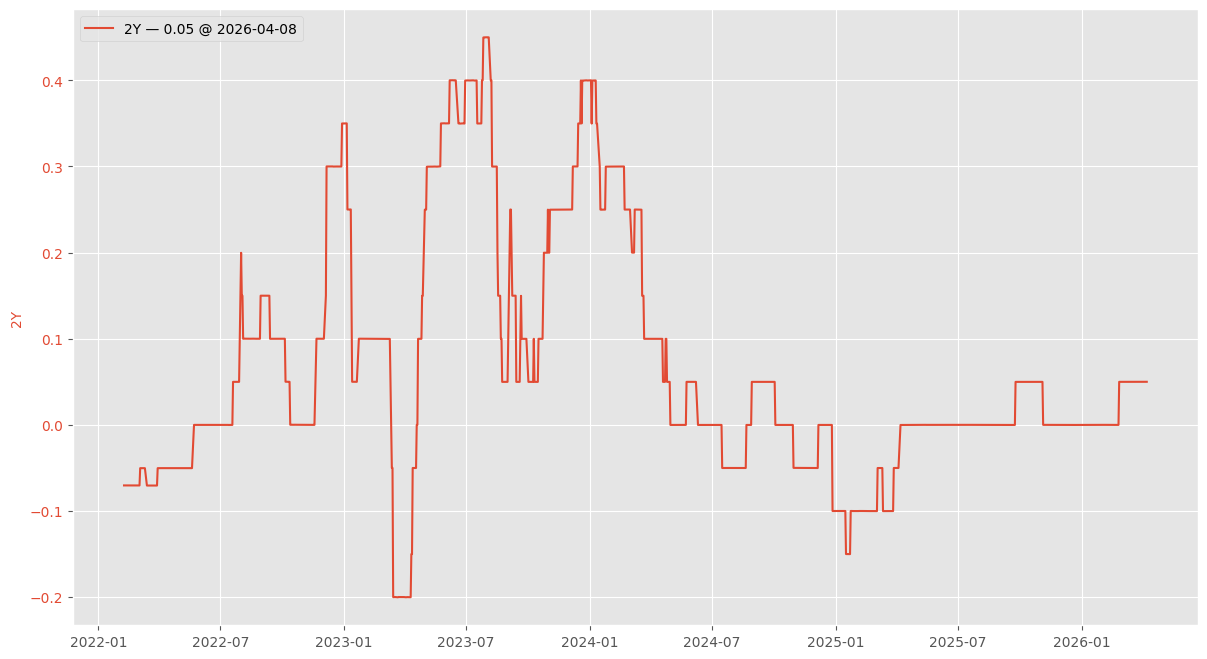

In [5]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot()
plot(pricer.basis_data["basis_bps"], label=pricer.meta_data["tenor"], which="left")
legend(show_date=True, loc="upper left")
plt.show()